## Loading intro stuff

In [1]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/constants.py"

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


In [2]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FUNCTIONS/load_functions"

fortran mie routines unavailable


/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:47: UserWarning: could not import compiled mie code - mie calculation will be slow
  warnings.warn(


In [3]:
%matplotlib inline

In [4]:
# VLA k band 9 mm (ish)
bands = ['Band 4 nterms2', 'Band 5', 'Band 6', 'Band 7 nterms2']
bands_naming = ['Band4_nterms2', 'Band5', 'Band6', 'Band7_nterms2']

band_colors = [alma_band_colors[b] for b in bands]
ms = [alma_band_ms[b] for b in bands]

In [5]:
df_POLF = load_POLF(bands)

In [6]:
# Load the CSV
df = pd.read_csv(P_omega_data_folder_path + "P_omega_vs_amax_f_0_3_CustomBounds.csv")

# Extract x-axis
a_max_f_dist_micron = df["a_max_f_micron"].values


P_times_omega = np.column_stack([df[f"P_times_omega_{b_name}"].values for b_name in bands_naming])

## Figure 4

(-0.1, 1.5)

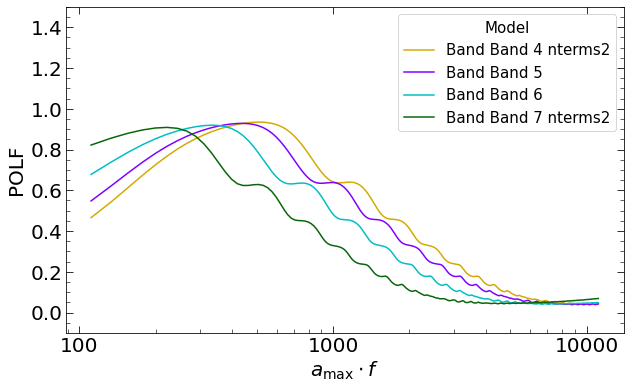

In [7]:
fig, ax = plot_a_vs_POLF(a_max_f_dist_micron, P_times_omega, 1, bands, y_plot = 'af',legend = 'wo sf')

ax.set_ylim(-0.1, 1.5)

## Find best $a_{max}$

The goal is to find the best grain size $a_{max}$ that makes the DSHARP model match the ovserved POLF as possible. 

For each $a_{max}$ we will find some scaling factor (sf) that will convert $P \omega$ to POLF

We need to find the value the minimuzes the sum of squares for EACH of the N_grains values of $a_{max}$

In [8]:
POLF_columns = ['POLF_Gaussian', 'POLF_maxPOLI', 'POLF_maxStokesI']

# Create base DataFrame with a_max column
df = pd.DataFrame({'a_max micron': a_max_f_dist_micron})

for j in range(len(POLF_columns)):
    col_name = POLF_columns[j]
    print(f'We are now testing {col_name}:')

    POLF_test = df_POLF[col_name]

    scale_factors = []
    diff_array = []

    for i in range(len(a_max_f_dist_micron)):
        result = minimize(
            dust_sum_of_sq,
            x0=0.01,
            args=(P_times_omega[i, :], POLF_test),
            bounds=[(0, None)]
        )

        sf_opt = result.x[0]
        err = result.fun

        scale_factors.append(sf_opt)
        diff_array.append(err)

    # Add columns to main df
    df[f'sf_{col_name}'] = scale_factors
    df[f'error_{col_name}'] = diff_array

We are now testing POLF_Gaussian:
We are now testing POLF_maxPOLI:
We are now testing POLF_maxStokesI:


In [9]:
best_index_array = []
best_error_array = []
best_a_max_f_array = []
best_sf_array = []

for col_name in POLF_columns:
    print(f'We are now testing {col_name}:')

    best_index = np.argmin(df[f'error_{col_name}'])
    best_error = df[f'error_{col_name}'][best_index]
    best_a_max_f = a_max_f_dist_micron[best_index]
    best_sf = df[f'sf_{col_name}'][best_index]

    best_index_array.append(best_index)
    best_error_array.append(best_error)
    best_a_max_f_array.append(best_a_max_f)
    best_sf_array.append(best_sf)

    print(f"   The index with the lowest error from minimize is    : {best_index}")
    print(f"   At this index, the corresponding error is           : {best_error:.3f}")
    print(f"   At this index, the corresponding a_max * f is       : {best_a_max_f:.1f} micron")
    print(f"   The scale factor at that a_max * f is               : {best_sf:.5f}")
    print(' ')

print(' ')
print(' ')

best_POLF_index = np.argmin(best_error_array)
best_POLF_column = POLF_columns[best_POLF_index]
best_POLF = df_POLF[best_POLF_column]
best_index = best_index_array[best_POLF_index]
best_error = best_error_array[best_POLF_index]
best_a_max_f = best_a_max_f_array[best_POLF_index]
best_sf = best_sf_array[best_POLF_index]


print(f'Out of the {len(df_POLF)} POLF options:')
print(f"   Lowest error occurs at POLF index of                 : {best_POLF_index}")
print(f"   This POLF index corresponds to                       : {best_POLF_column}")   
print(f"   The POLFs at this best POLF column are               : {best_POLF[0]:.3f},  {best_POLF[1]:.3f},  {best_POLF[2]:.3f}")
print(f"   The index with the lowest error from minimize is     : {best_index}")
print(f"   At this index, the corresponding error is            : {best_error:.3f}")
print(f"   At this index, the corresponding a_max * f is        : {best_a_max_f:.1f} micron")
print(f"   The scale factor at that a_max * f is                : {best_sf:.5f}")


We are now testing POLF_Gaussian:
   The index with the lowest error from minimize is    : 12
   At this index, the corresponding error is           : 0.150
   At this index, the corresponding a_max * f is       : 375.6 micron
   The scale factor at that a_max * f is               : 1.27784
 
We are now testing POLF_maxPOLI:
   The index with the lowest error from minimize is    : 32
   At this index, the corresponding error is           : 0.169
   At this index, the corresponding a_max * f is       : 816.5 micron
   The scale factor at that a_max * f is               : 2.05658
 
We are now testing POLF_maxStokesI:
   The index with the lowest error from minimize is    : 10
   At this index, the corresponding error is           : 0.138
   At this index, the corresponding a_max * f is       : 331.6 micron
   The scale factor at that a_max * f is               : 1.38731
 
 
 
Out of the 4 POLF options:
   Lowest error occurs at POLF index of                 : 2
   This POLF index corresp

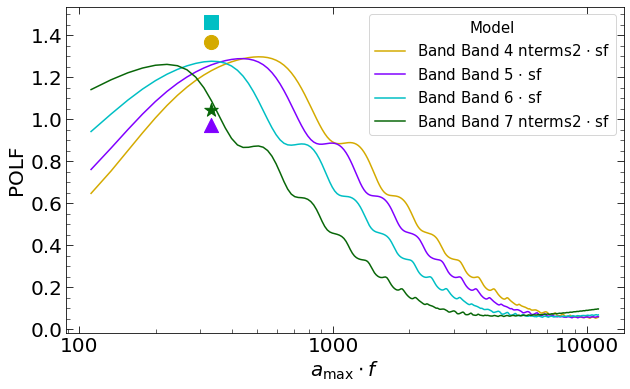

In [10]:
fig, ax = plot_a_vs_POLF(a_max_f_dist_micron, P_times_omega, best_sf, bands, y_plot = 'af', legend = 'w sf')

for i in range(len(bands)):
    ax.scatter(best_a_max_f, best_POLF[i], c = band_colors[i], marker = ms[i], s = 200)

add an upper limit of 3 sigma with VLA non-detection